# Loss function plots

Notebook dedie aux courbes de loss:

- switching predictive LOSO: loss par utilisateur/fold;
- switching final model: validation/refit losses;
- fusion model: train/validation losses si l'historique existe;
- decomposition `factor_loss` vs `state_loss`.

Ce notebook ne lance pas l'entrainement. Il lit seulement les fichiers `history.csv`, `loss_history.csv` et `metrics.json` deja produits dans `outputs/`.

## 1. Setup

In [1]:
from pathlib import Path
import json
import math
import sys

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "fusion_model.py").is_file():
            return candidate
    raise RuntimeError("Could not find project root containing fusion_model.py")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
SWITCHING_DIR = OUTPUTS / "switching_predictive"
SWITCHING_FINAL_DIR = SWITCHING_DIR / "final"
FUSION_TRAIN_DIR = OUTPUTS / "fusion_train"
FUSION_SMOKE_TRAIN_DIR = OUTPUTS / "fusion_train_smoke"

plt.style.use("seaborn-v0_8-whitegrid")
print("ROOT:", ROOT)
print("SWITCHING_DIR exists:", SWITCHING_DIR.exists())
print("SWITCHING_FINAL_DIR exists:", SWITCHING_FINAL_DIR.exists())

ROOT: C:\Users\medte\OneDrive\Desktop\Fusion_Model
SWITCHING_DIR exists: True
SWITCHING_FINAL_DIR exists: True


In [2]:
def read_json(path: Path):
    if not path.is_file():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def load_switching_fold_histories(base_dir: Path) -> pd.DataFrame:
    frames = []
    for path in sorted(base_dir.glob("fold_*/history.csv")):
        df = pd.read_csv(path)
        user = path.parent.name.replace("fold_", "", 1)
        df["user"] = user
        df["history_path"] = str(path.relative_to(ROOT))
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def plot_metric_by_user(history: pd.DataFrame, metric: str, title: str, ylabel: str = "loss"):
    if history.empty or metric not in history.columns:
        print(f"No data for {metric}")
        return
    fig, ax = plt.subplots(figsize=(12, 5))
    for user, df in history.groupby("user"):
        ax.plot(df["epoch"], df[metric], marker="o", linewidth=1.4, alpha=0.85, label=user)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="user")
    plt.tight_layout()
    plt.show()


def plot_history_pair(df: pd.DataFrame, title: str, train_col: str = "train_loss", val_col: str = "val_loss"):
    if df is None or df.empty:
        print(f"No history for {title}")
        return
    fig, ax = plt.subplots(figsize=(9, 4))
    if train_col in df.columns:
        ax.plot(df["epoch"], df[train_col], marker="o", label=train_col)
    if val_col in df.columns:
        ax.plot(df["epoch"], df[val_col], marker="o", label=val_col)
        best_idx = df[val_col].idxmin()
        best = df.loc[best_idx]
        ax.axvline(best["epoch"], color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax.scatter([best["epoch"]], [best[val_col]], color="black", zorder=5)
        ax.text(best["epoch"], best[val_col], f" best epoch {int(best['epoch'])}", va="bottom")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2. Switching predictive LOSO losses by user

Chaque `fold_<user>/history.csv` correspond a un modele entraine avec ce user laisse en test. La `val_loss` sert a choisir `best.pt` dans ce fold.

In [3]:
switching_history = load_switching_fold_histories(SWITCHING_DIR)
print("rows:", len(switching_history))
print("users:", sorted(switching_history["user"].unique().tolist()) if not switching_history.empty else [])
display(switching_history.head())

rows: 179
users: ['Graja', 'Makki', 'amrdroid', 'dem', 'ghoss', 'hffz', 'ignorant', 'ladabos', 'layss', 'mohanned']


,epoch,train_loss,train_factor_loss,train_state_loss,train_state_accuracy,train_num_samples,val_loss,val_factor_loss,val_state_loss,val_state_accuracy,val_num_samples,user,history_path
0,1,0.995701,0.110831,1.585615,0.314706,340.0,0.939549,0.099437,1.499624,0.0,15.0,amrdroid,outputs\switching_predictive\fold_amrdroid\his...
1,2,0.932717,0.046167,1.523749,0.326471,340.0,0.804191,0.031805,1.319115,0.0,15.0,amrdroid,outputs\switching_predictive\fold_amrdroid\his...
2,3,0.925675,0.041591,1.515064,0.326471,340.0,0.777367,0.045039,1.265586,0.0,15.0,amrdroid,outputs\switching_predictive\fold_amrdroid\his...
3,4,0.919487,0.035725,1.508662,0.326471,340.0,0.811406,0.056332,1.314790,0.0,15.0,amrdroid,outputs\switching_predictive\fold_amrdroid\his...
4,5,0.916351,0.033498,1.504920,0.326471,340.0,0.783242,0.036550,1.281036,0.0,15.0,amrdroid,outputs\switching_predictive\fold_amrdroid\his...


In [4]:
if not switching_history.empty:
    best_rows = switching_history.loc[switching_history.groupby("user")["val_loss"].idxmin()].copy()
    best_rows = best_rows.sort_values("val_loss")
    cols = [
        "user", "epoch", "train_loss", "val_loss",
        "train_factor_loss", "val_factor_loss",
        "train_state_loss", "val_state_loss",
        "train_state_accuracy", "val_state_accuracy",
        "val_num_samples",
    ]
    display(best_rows[[c for c in cols if c in best_rows.columns]])
else:
    print("No switching fold histories found.")

,user,epoch,train_loss,val_loss,train_factor_loss,val_factor_loss,train_state_loss,val_state_loss,train_state_accuracy,val_state_accuracy,val_num_samples
25,dem,4,0.908910,0.487920,0.054830,0.008957,1.478297,0.807229,0.386598,1.00000,16.0
153,Makki,2,0.912392,0.641011,0.046186,0.002004,1.489862,1.067016,0.308824,1.00000,16.0
76,Graja,22,0.904249,0.675019,0.031899,0.039307,1.485816,1.098827,0.313043,1.00000,15.0
9,amrdroid,10,0.916286,0.765933,0.032303,0.039927,1.505608,1.249937,0.326471,0.00000,15.0
42,ghoss,5,0.918036,0.775922,0.032812,0.044441,1.508185,1.263576,0.326471,0.00000,16.0
96,hffz,8,0.757051,0.904250,0.020349,0.071461,1.248186,1.459443,0.364662,0.40625,64.0
126,ladabos,5,0.910612,0.920777,0.025199,0.070525,1.500886,1.487611,0.326460,0.25000,64.0
166,mohanned,1,0.992857,1.030534,0.100319,0.099183,1.587882,1.651435,0.278351,0.21118,161.0
139,layss,1,0.998281,1.042524,0.133084,0.125896,1.575079,1.653608,0.445205,0.21118,161.0
109,ignorant,1,0.984663,1.150823,0.112170,0.182465,1.566325,1.796395,0.283439,0.04878,41.0


### 2.1 All users on one plot

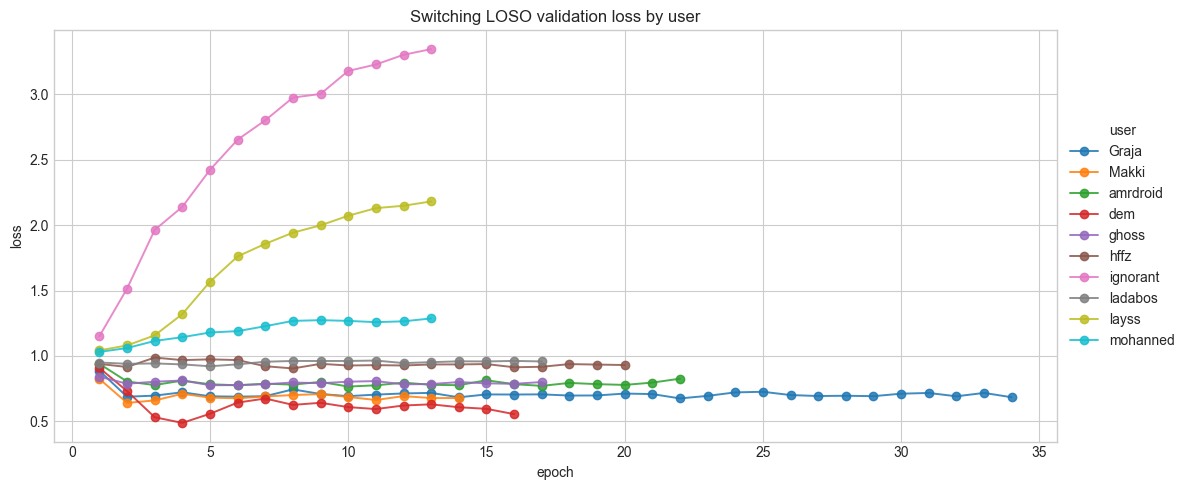

In [5]:
plot_metric_by_user(switching_history, "val_loss", "Switching LOSO validation loss by user")

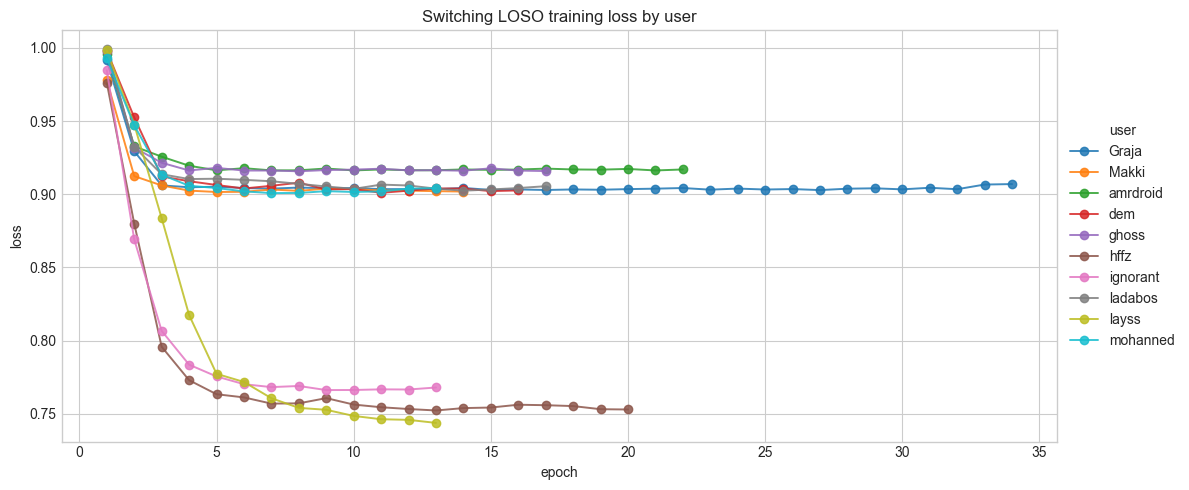

In [6]:
plot_metric_by_user(switching_history, "train_loss", "Switching LOSO training loss by user")

### 2.2 One subplot per user

Ici on voit si un fold overfit: `train_loss` descend mais `val_loss` monte ou reste instable.

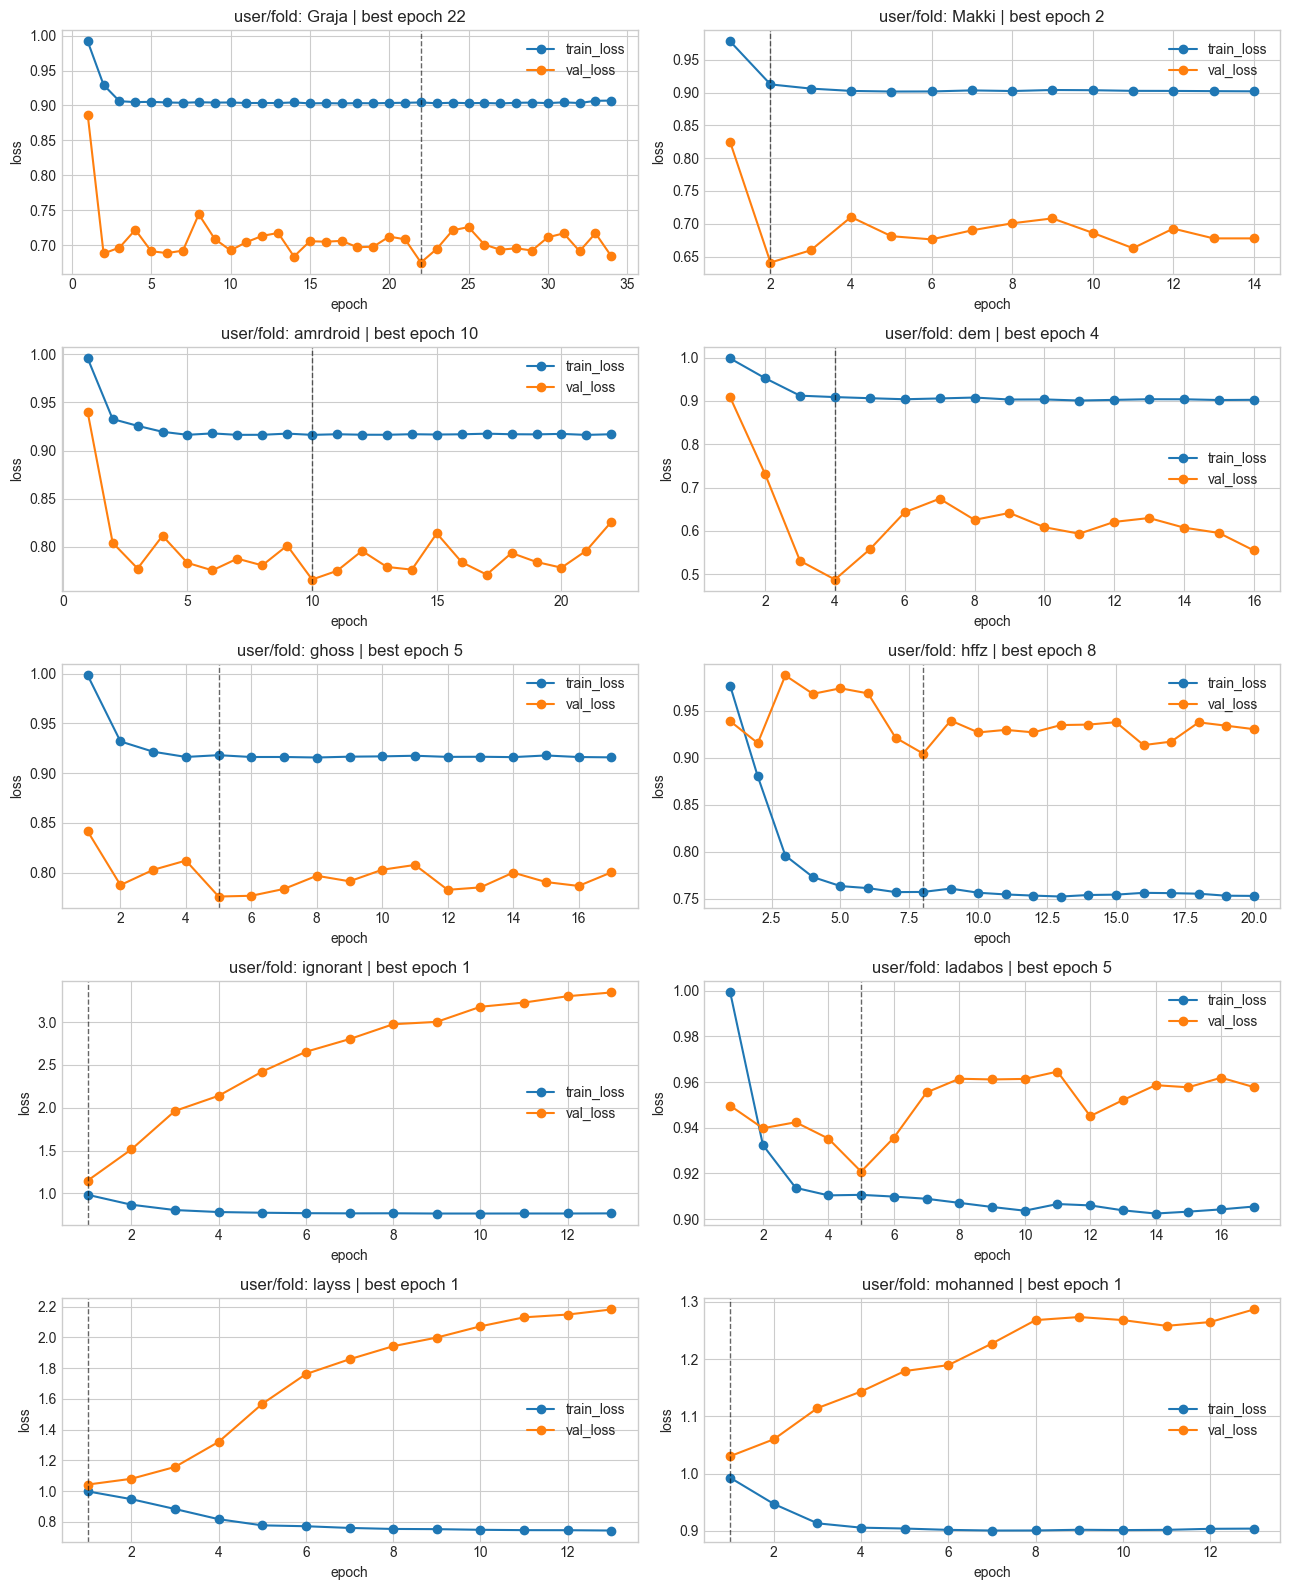

In [7]:
if not switching_history.empty:
    users = sorted(switching_history["user"].unique().tolist())
    ncols = 2
    nrows = math.ceil(len(users) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
    for ax, user in zip(axes.ravel(), users):
        df = switching_history[switching_history["user"] == user].sort_values("epoch")
        ax.plot(df["epoch"], df["train_loss"], marker="o", label="train_loss")
        ax.plot(df["epoch"], df["val_loss"], marker="o", label="val_loss")
        best = df.loc[df["val_loss"].idxmin()]
        ax.axvline(best["epoch"], color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_title(f"user/fold: {user} | best epoch {int(best['epoch'])}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()
    for ax in axes.ravel()[len(users):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No switching histories to plot.")

### 2.3 Best validation loss per user

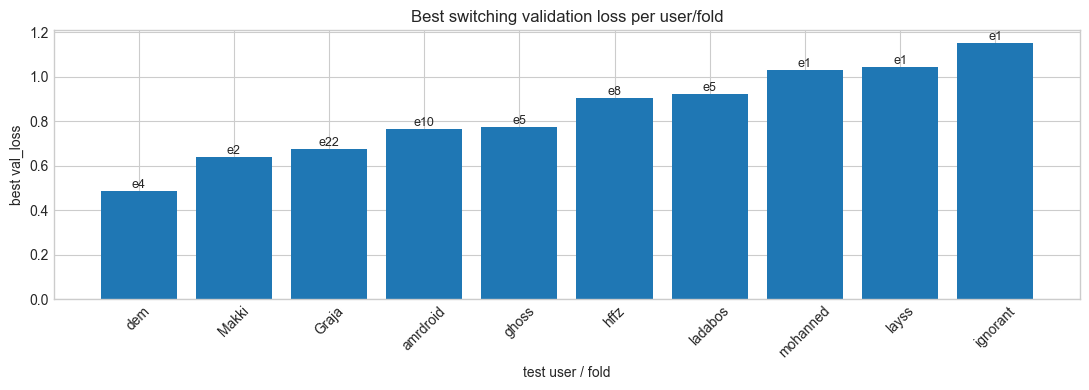

In [8]:
if not switching_history.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    plot_df = best_rows.sort_values("val_loss")
    ax.bar(plot_df["user"], plot_df["val_loss"])
    ax.set_title("Best switching validation loss per user/fold")
    ax.set_xlabel("test user / fold")
    ax.set_ylabel("best val_loss")
    ax.tick_params(axis="x", rotation=45)
    for idx, row in enumerate(plot_df.itertuples(index=False)):
        ax.text(idx, getattr(row, "val_loss"), f"e{int(getattr(row, 'epoch'))}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No best rows to plot.")

## 3. Factor loss vs state loss by user

La loss totale est:

`loss = 0.4 * factor_loss + 0.6 * state_loss`

Ces plots montrent quelle partie domine par fold.

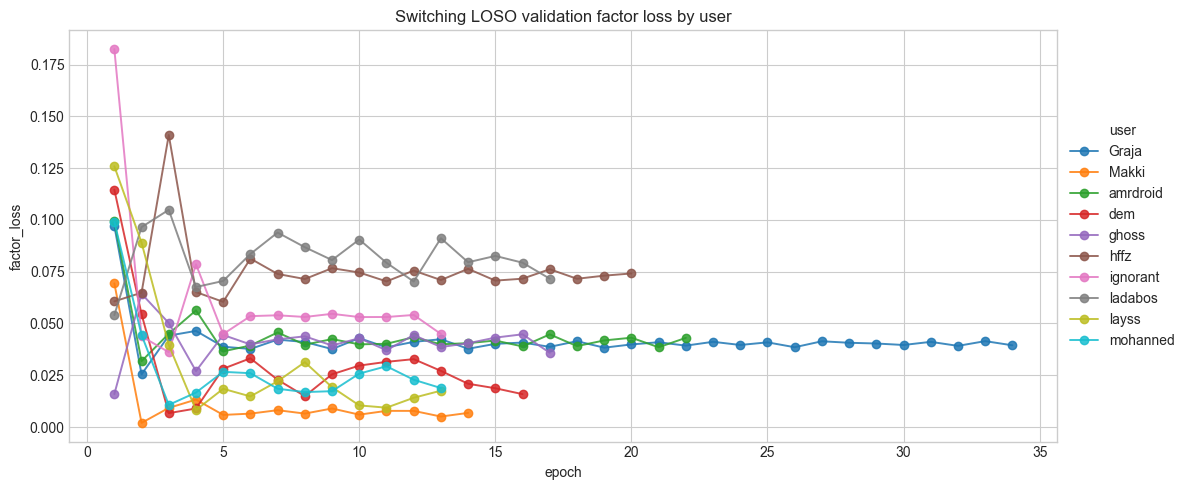

In [9]:
plot_metric_by_user(switching_history, "val_factor_loss", "Switching LOSO validation factor loss by user", ylabel="factor_loss")

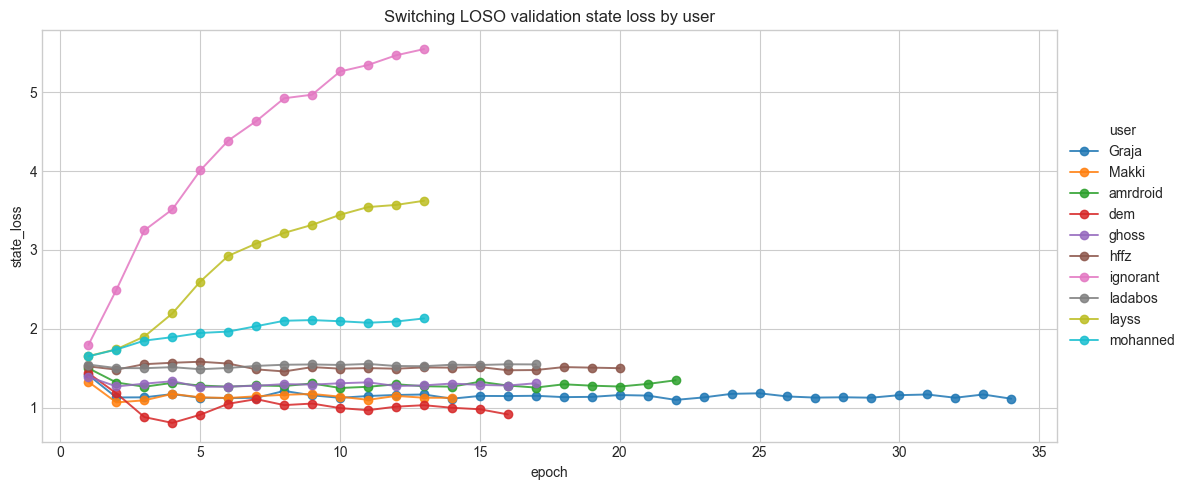

In [10]:
plot_metric_by_user(switching_history, "val_state_loss", "Switching LOSO validation state loss by user", ylabel="state_loss")

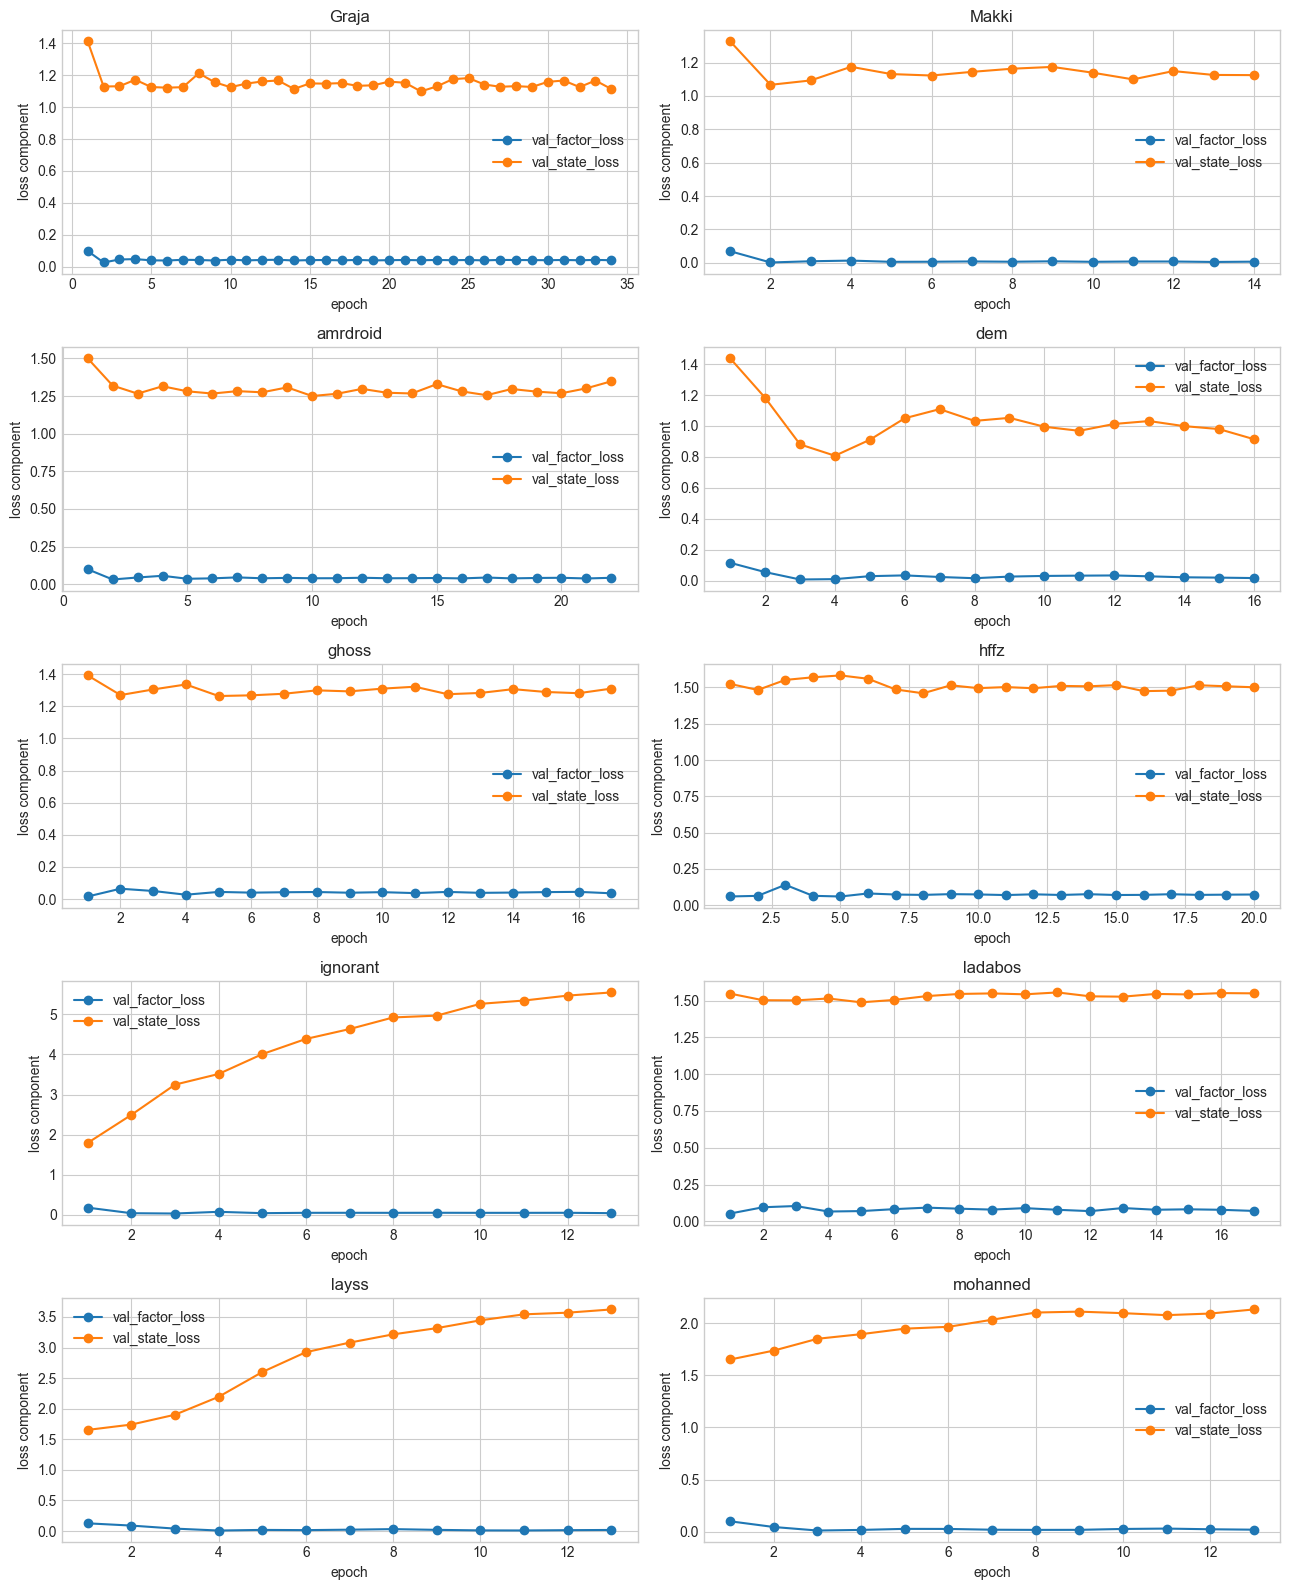

In [11]:
if not switching_history.empty:
    users = sorted(switching_history["user"].unique().tolist())
    ncols = 2
    nrows = math.ceil(len(users) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
    for ax, user in zip(axes.ravel(), users):
        df = switching_history[switching_history["user"] == user].sort_values("epoch")
        ax.plot(df["epoch"], df["val_factor_loss"], marker="o", label="val_factor_loss")
        ax.plot(df["epoch"], df["val_state_loss"], marker="o", label="val_state_loss")
        ax.set_title(user)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss component")
        ax.legend()
    for ax in axes.ravel()[len(users):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No switching histories to plot.")

## 4. Switching final model losses

`validation_history.csv` montre la phase avec validation. `refit_history.csv` montre le modele final re-entraine/refit sur les donnees finales.

In [12]:
validation_path = SWITCHING_FINAL_DIR / "validation_history.csv"
refit_path = SWITCHING_FINAL_DIR / "refit_history.csv"
final_summary_path = SWITCHING_FINAL_DIR / "final_training_summary.json"

validation_history = pd.read_csv(validation_path) if validation_path.is_file() else pd.DataFrame()
refit_history = pd.read_csv(refit_path) if refit_path.is_file() else pd.DataFrame()
final_summary = read_json(final_summary_path)

print("validation_history:", validation_path.exists(), validation_history.shape)
print("refit_history:", refit_path.exists(), refit_history.shape)
if final_summary:
    display(pd.DataFrame([final_summary]))

validation_history: True (13, 11)
refit_history: True (1, 6)


,best_epoch_from_validation,checkpoint,data_dir,device,num_samples,num_users,trained_on_all_samples,validation_loss
0,1,outputs\switching_predictive\final\best.pt,data_training,cpu,371,10,True,1.116427


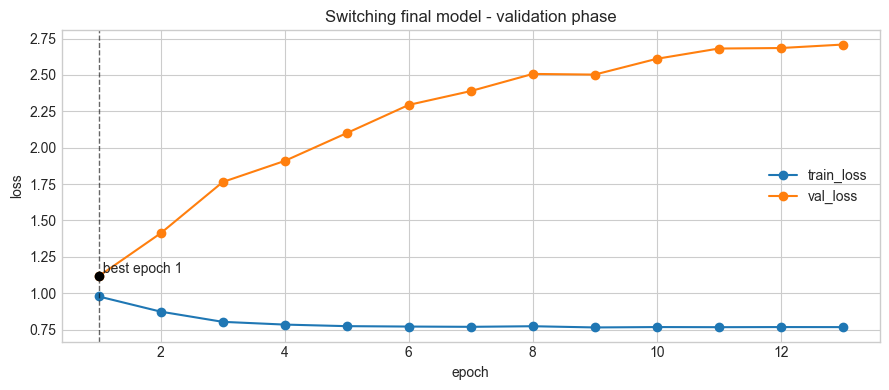

In [13]:
plot_history_pair(validation_history, "Switching final model - validation phase")

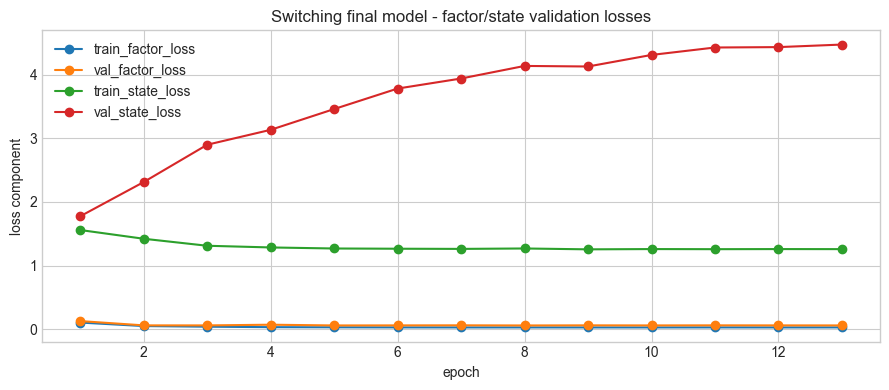

In [14]:
if not validation_history.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    for col in ["train_factor_loss", "val_factor_loss", "train_state_loss", "val_state_loss"]:
        if col in validation_history.columns:
            ax.plot(validation_history["epoch"], validation_history[col], marker="o", label=col)
    ax.set_title("Switching final model - factor/state validation losses")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss component")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No validation history for final switching model.")

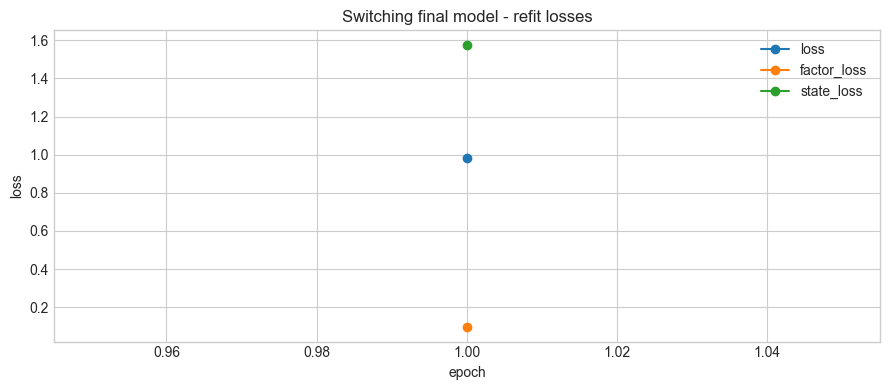

In [15]:
if not refit_history.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    for col in ["loss", "factor_loss", "state_loss"]:
        if col in refit_history.columns:
            ax.plot(refit_history["epoch"], refit_history[col], marker="o", label=col)
    ax.set_title("Switching final model - refit losses")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No refit history for final switching model.")

## 5. Fusion model losses

Si `outputs/fusion_train/loss_history.csv` n'existe pas encore, le notebook utilise le run smoke `outputs/fusion_train_smoke/loss_history.csv`.

In [16]:
fusion_history_path = None
for candidate in [FUSION_TRAIN_DIR / "loss_history.csv", FUSION_SMOKE_TRAIN_DIR / "loss_history.csv"]:
    if candidate.is_file():
        fusion_history_path = candidate
        break

fusion_history = pd.read_csv(fusion_history_path) if fusion_history_path else pd.DataFrame()
print("fusion_history_path:", fusion_history_path.relative_to(ROOT) if fusion_history_path else None)
display(fusion_history)

fusion_history_path: outputs\fusion_train_smoke\loss_history.csv


,epoch,train_loss,train_factor_loss,train_state_loss,train_state_accuracy,train_factor_mae,train_num_samples,val_loss,val_factor_loss,val_state_loss,val_state_accuracy,val_factor_mae,val_num_samples
0,1,0.829776,0.063158,1.340855,0.5,0.335182,2.0,1.247063,0.164683,1.96865,0.0,0.394406,2.0


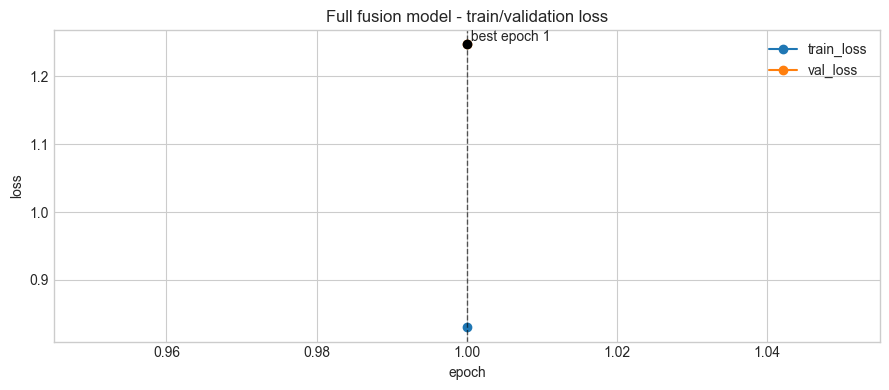

In [17]:
plot_history_pair(fusion_history, "Full fusion model - train/validation loss")

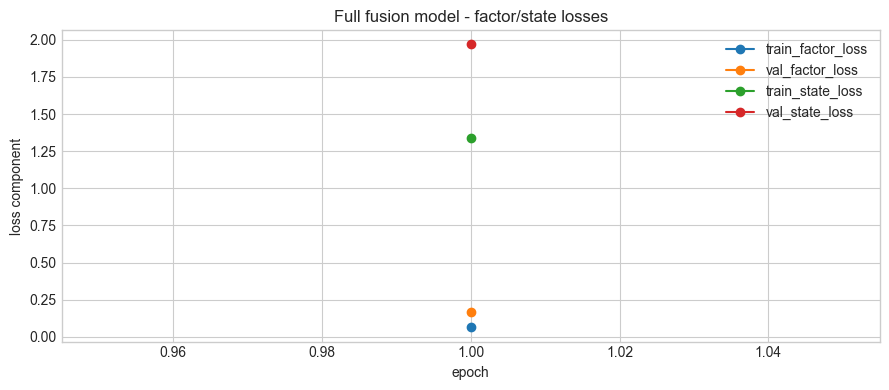

In [18]:
if not fusion_history.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    for col in ["train_factor_loss", "val_factor_loss", "train_state_loss", "val_state_loss"]:
        if col in fusion_history.columns:
            ax.plot(fusion_history["epoch"], fusion_history[col], marker="o", label=col)
    ax.set_title("Full fusion model - factor/state losses")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss component")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No fusion history to plot.")

## 6. Quick reading guide

- `train_loss` descend mais `val_loss` monte: overfitting probable.
- `val_state_loss` domine: le probleme principal est la classification des etats.
- `val_factor_loss` domine: le probleme principal est la regression des facteurs NASA-TLX normalises.
- Fold avec `best val_loss` tres elevee: utilisateur difficile, labels bruités, ou distribution differente.
- Le modele final unique n'est pas une validation unbiased; les folds LOSO sont la reference pour generalisation.